<a href="https://colab.research.google.com/github/Bhavana546/Shopper_Spectrum_Customer_Segmentation/blob/main/Shopper_Spectrum_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

## 📌 Project Overview
This project analyzes e-commerce transaction data to understand customer purchasing behavior, create customer segments using RFM analysis and KMeans clustering, and recommend similar products using item-based collaborative filtering.

## 🎯 Objectives
- Clean and preprocess e-commerce transaction data
- Perform Exploratory Data Analysis (EDA)
- Create RFM features: Recency, Frequency, and Monetary value
- Segment customers using KMeans clustering
- Build an item-based product recommendation system
- Develop a Streamlit application for predictions and recommendations

## 🧠 Machine Learning Techniques Used
- Unsupervised Learning: KMeans Clustering
- Recommendation System: Item-Based Collaborative Filtering
- Similarity Metric: Cosine Similarity

## 🛠 Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit
- Joblib

Step 1: Dataset Collection and Understanding

In [2]:
# ============================================================
# STEP 1: DATASET COLLECTION AND UNDERSTANDING
# ============================================================

# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style for better-looking visualizations
sns.set_style("whitegrid")

# Load the Online Retail CSV dataset into a Pandas DataFrame
df = pd.read_csv("online_retail.csv", encoding="latin1")

# Display the first 5 rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# ============================================================
# DATASET STRUCTURE
# ============================================================

# Print the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types and non-null values for each column
print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Step 1.2 — Check Missing Values, Duplicates, and Unusual Records

In [4]:
# ============================================================
# MISSING VALUES ANALYSIS
# ============================================================

# Count missing values in every column
missing_values = df.isnull().sum()

# Calculate missing value percentage for every column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine missing value count and percentage into one table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

# Display missing value summary
print("Missing Values Summary:")
display(missing_summary)

Missing Values Summary:


,Missing Values,Missing Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [5]:
# ============================================================
# DUPLICATE RECORDS ANALYSIS
# ============================================================

# Count duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

# Display duplicate count
print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 5268


In [6]:
# ============================================================
# UNUSUAL RECORDS ANALYSIS
# ============================================================

# Count rows where quantity is zero or negative
invalid_quantity = df[df["Quantity"] <= 0].shape[0]

# Count rows where unit price is zero or negative
invalid_price = df[df["UnitPrice"] <= 0].shape[0]

# Count cancelled invoices.
# Cancelled invoice numbers usually begin with the letter "C".
cancelled_invoices = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
].shape[0]

# Display unusual record counts
print("Transactions with Quantity <= 0:", invalid_quantity)
print("Transactions with UnitPrice <= 0:", invalid_price)
print("Cancelled Invoice Records:", cancelled_invoices)

Transactions with Quantity <= 0: 10624
Transactions with UnitPrice <= 0: 2517
Cancelled Invoice Records: 9288


## Step 2: Data Preprocessing

In this step, the dataset is cleaned by removing missing customer IDs, missing product descriptions, duplicate records, cancelled invoices, and invalid transactions. The InvoiceDate column is also converted into datetime format for later RFM analysis.

In [7]:
# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================

# Create a copy of the original dataset.
# This keeps the original df safe in case we need it later.
df_clean = df.copy()

# Store the original number of rows before cleaning.
original_rows = df_clean.shape[0]

# ------------------------------------------------------------
# 1. Remove rows where CustomerID is missing.
# CustomerID is required for customer segmentation and
# collaborative filtering recommendations.
# ------------------------------------------------------------
df_clean = df_clean.dropna(subset=["CustomerID"])

# ------------------------------------------------------------
# 2. Remove rows where product Description is missing.
# Product description is needed for product recommendations.
# ------------------------------------------------------------
df_clean = df_clean.dropna(subset=["Description"])

# ------------------------------------------------------------
# 3. Remove duplicate transaction records.
# ------------------------------------------------------------
df_clean = df_clean.drop_duplicates()

# ------------------------------------------------------------
# 4. Remove cancelled invoices.
# Cancelled invoices start with the letter "C".
# ------------------------------------------------------------
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# ------------------------------------------------------------
# 5. Remove transactions with zero or negative quantity.
# These usually represent returns, cancellations, or errors.
# ------------------------------------------------------------
df_clean = df_clean[df_clean["Quantity"] > 0]

# ------------------------------------------------------------
# 6. Remove transactions with zero or negative unit price.
# These are invalid for monetary calculations.
# ------------------------------------------------------------
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# ------------------------------------------------------------
# 7. Convert InvoiceDate column from text/object to datetime.
# This is required for time-based analysis and RFM features.
# ------------------------------------------------------------
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# ------------------------------------------------------------
# 8. Convert CustomerID from float to integer.
# Customer IDs should be stored as whole numbers.
# ------------------------------------------------------------
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# ------------------------------------------------------------
# 9. Create a new column called TotalAmount.
# TotalAmount = Quantity × UnitPrice
# This will be used to calculate Monetary value in RFM analysis.
# ------------------------------------------------------------
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Display the first 5 cleaned rows.
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [8]:
# ============================================================
# DATA CLEANING VERIFICATION
# ============================================================

# Display the dataset shape before and after cleaning.
print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

# Calculate the number of removed rows.
removed_rows = original_rows - df_clean.shape[0]

print("\nTotal Rows Removed:", removed_rows)

# Check whether missing values still exist.
print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

# Check duplicate rows after cleaning.
print("\nDuplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())

# Check invalid quantity records after cleaning.
print("\nTransactions with Quantity <= 0:")
print(df_clean[df_clean["Quantity"] <= 0].shape[0])

# Check invalid price records after cleaning.
print("\nTransactions with UnitPrice <= 0:")
print(df_clean[df_clean["UnitPrice"] <= 0].shape[0])

# Check cancelled invoices after cleaning.
print("\nCancelled Invoice Records:")
print(
    df_clean[
        df_clean["InvoiceNo"].astype(str).str.startswith("C")
    ].shape[0]
)

Original Dataset Shape: (541909, 8)
Cleaned Dataset Shape: (392692, 9)

Total Rows Removed: 149217

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate Rows After Cleaning:
0

Transactions with Quantity <= 0:
0

Transactions with UnitPrice <= 0:
0

Cancelled Invoice Records:
0


##  Step 3: Exploratory Data Analysis (EDA)

### 3.1 Transaction Volume by Country

This analysis identifies the countries with the highest number of transactions. It helps understand where most customers are located and which markets generate the most sales activity.

In [9]:
# ============================================================
# EDA 1: TRANSACTION VOLUME BY COUNTRY
# ============================================================

# Count the number of transaction records for each country.
# Each row represents one purchased product in an invoice.
country_transactions = (
    df_clean.groupby("Country")
    .size()
    .sort_values(ascending=False)
)

# Display the top 10 countries with the highest transaction volume.
print("Top 10 Countries by Transaction Volume:")
display(country_transactions.head(10))

Top 10 Countries by Transaction Volume:


,0
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


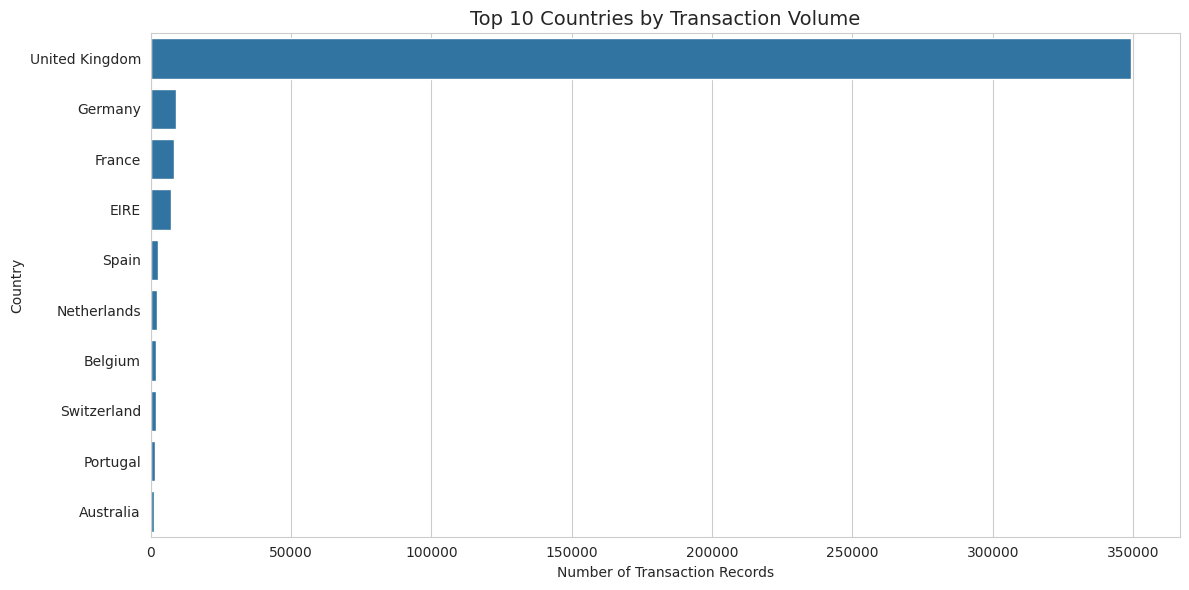

In [11]:
# ============================================================
# VISUALIZATION: TOP 10 COUNTRIES BY TRANSACTION VOLUME
# ============================================================

# Select only the top 10 countries for a readable chart.
top_10_countries = country_transactions.head(10)

# Create a bar chart.
plt.figure(figsize=(12, 6))

# Plot transaction volume by country.
sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index
)

# Add chart title and axis labels.
plt.title("Top 10 Countries by Transaction Volume", fontsize=14)
plt.xlabel("Number of Transaction Records")
plt.ylabel("Country")

# Adjust layout so labels do not overlap.
plt.tight_layout()

# Display the chart.
plt.show()

### 3.2 Top-Selling Products

This analysis identifies the products with the highest total quantity sold. It helps the business understand which products are most popular and can support inventory planning.

In [12]:
# ============================================================
# EDA 2: TOP-SELLING PRODUCTS
# ============================================================

# Group the dataset by product description.
# Sum the Quantity column to find total units sold for each product.
top_products = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 products with the highest quantity sold.
print("Top 10 Best-Selling Products:")
display(top_products.head(10))

Top 10 Best-Selling Products:


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


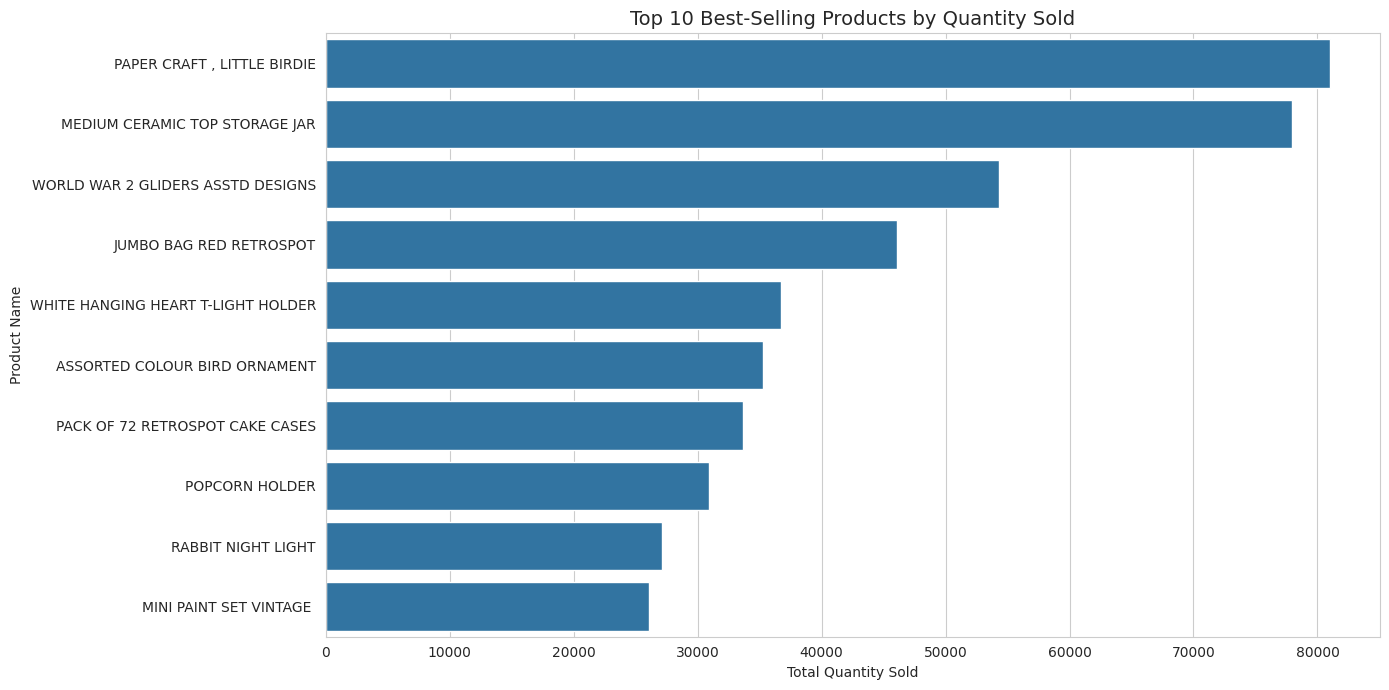

In [13]:
# ============================================================
# VISUALIZATION: TOP 10 BEST-SELLING PRODUCTS
# ============================================================

# Select the top 10 products for visualization.
top_10_products = top_products.head(10)

# Create a bar chart.
plt.figure(figsize=(14, 7))

# Plot products and their total quantity sold.
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

# Add chart title and axis labels.
plt.title("Top 10 Best-Selling Products by Quantity Sold", fontsize=14)
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")

# Adjust layout to avoid overlapping labels.
plt.tight_layout()

# Display the chart.
plt.show()

### 3.3 Purchase Trends Over Time

This analysis shows how customer purchases change over time. It helps identify busy months, seasonal demand, and periods with higher sales activity.

In [14]:
# ============================================================
# EDA 3: PURCHASE TRENDS OVER TIME
# ============================================================

# Create a new column containing only the year and month
# from the InvoiceDate column.
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

# Group transactions by month.
# Sum TotalAmount to calculate total sales for every month.
monthly_sales = (
    df_clean.groupby("YearMonth")["TotalAmount"]
    .sum()
    .reset_index()
)

# Convert YearMonth back to string for better display.
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

# Display monthly sales values.
print("Monthly Sales Trend:")
display(monthly_sales)

Monthly Sales Trend:


,YearMonth,TotalAmount
0,2022-12,570422.730
1,2023-01,568101.310
2,2023-02,446084.920
3,2023-03,594081.760
4,2023-04,468374.331
5,2023-05,677355.150
6,2023-06,660046.050
7,2023-07,598962.901
8,2023-08,644051.040
9,2023-09,950690.202


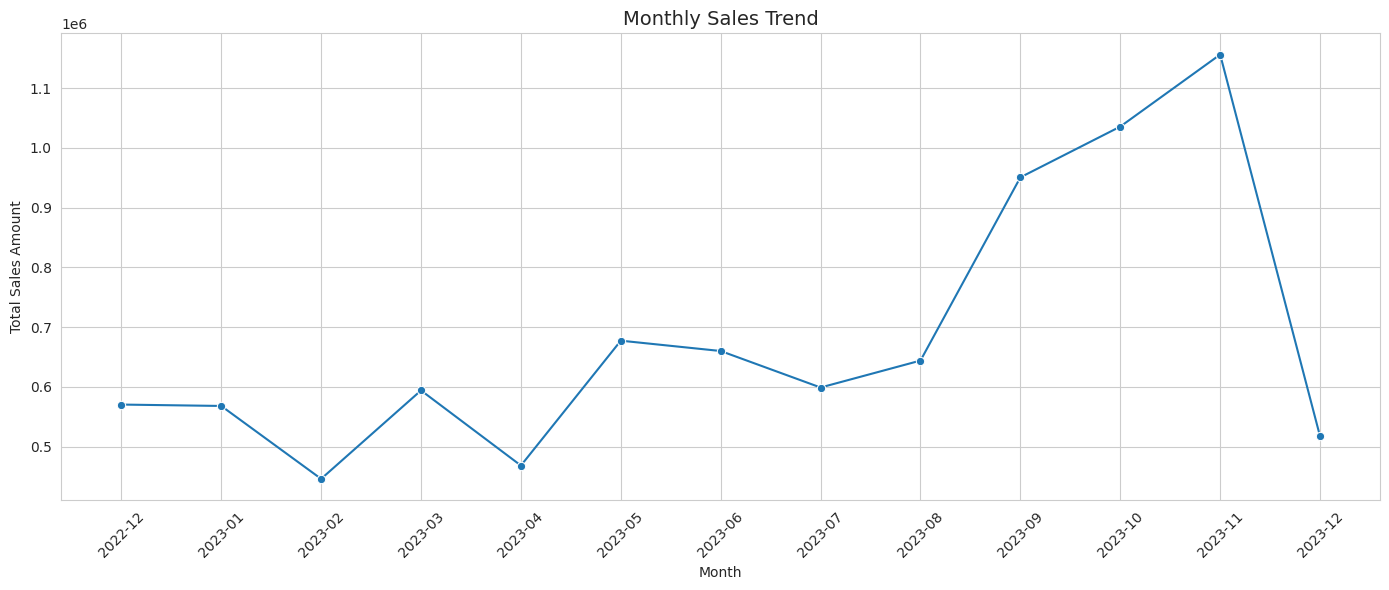

In [15]:
# ============================================================
# VISUALIZATION: MONTHLY SALES TREND
# ============================================================

# Create a line chart to show total sales over time.
plt.figure(figsize=(14, 6))

# Plot monthly sales trend.
sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="TotalAmount",
    marker="o"
)

# Add chart title and axis labels.
plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")

# Rotate month labels so they are readable.
plt.xticks(rotation=45)

# Adjust layout.
plt.tight_layout()

# Display the chart.
plt.show()

### 3.4 Monetary Distribution per Transaction and Customer

This analysis examines how much money is spent in individual transactions and by customers overall. It helps identify whether most purchases are low-value or high-value and highlights possible high-spending customers.

Transaction Amount Summary:


,TotalAmount
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


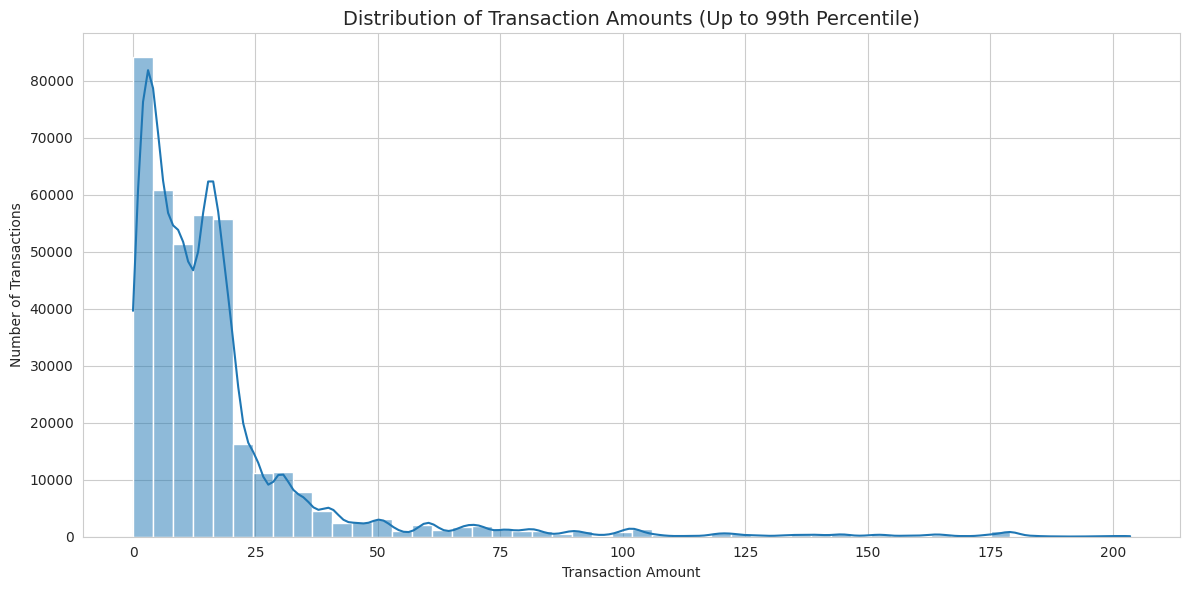

In [16]:
# ============================================================
# EDA 4: MONETARY DISTRIBUTION PER TRANSACTION
# ============================================================

# Display summary statistics for transaction-level total amount.
print("Transaction Amount Summary:")
display(df_clean["TotalAmount"].describe())

# Create a histogram for transaction amount distribution.
# Values above the 99th percentile are removed only for visualization,
# so extreme outliers do not hide the main distribution.
transaction_limit = df_clean["TotalAmount"].quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    df_clean[df_clean["TotalAmount"] <= transaction_limit]["TotalAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amounts (Up to 99th Percentile)", fontsize=14)
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Customer Total Spending Summary:


,TotalAmount
count,4338.000000
mean,2048.688081
std,8985.230220
min,3.750000
25%,306.482500
50%,668.570000
75%,1660.597500
max,280206.020000


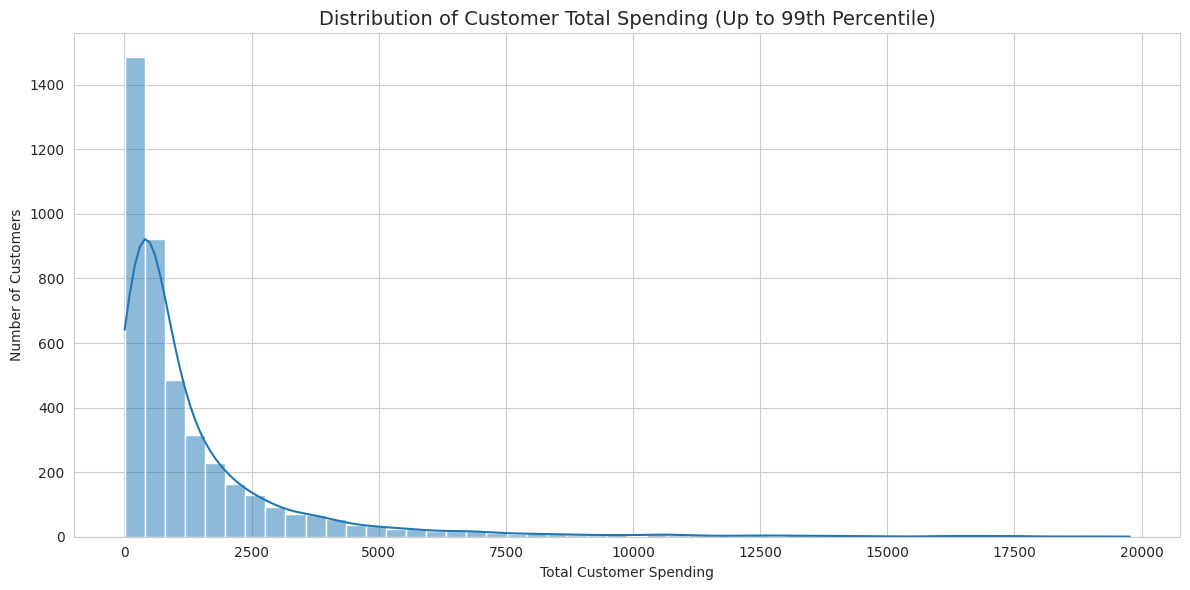

In [17]:
# ============================================================
# EDA 5: MONETARY DISTRIBUTION PER CUSTOMER
# ============================================================

# Calculate total spending by each customer.
customer_total_spending = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

# Display summary statistics for customer-level spending.
print("Customer Total Spending Summary:")
display(customer_total_spending.describe())

# Remove the top 1% extreme spenders only for chart readability.
customer_limit = customer_total_spending.quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    customer_total_spending[customer_total_spending <= customer_limit],
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Total Spending (Up to 99th Percentile)", fontsize=14)
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 📌 Step 4: RFM Feature Engineering

RFM analysis is used to understand customer purchasing behavior.

- **Recency:** Number of days since the customer's last purchase
- **Frequency:** Number of unique transactions made by the customer
- **Monetary:** Total amount spent by the customer

In [18]:
# ============================================================
# STEP 4: RFM FEATURE ENGINEERING
# ============================================================

# Find the latest purchase date available in the cleaned dataset.
# This date will be used as the reference date for Recency calculation.
latest_date = df_clean["InvoiceDate"].max()

# Add one day to the latest date.
# This ensures customers who purchased on the latest date
# will have Recency = 1 instead of 0.
reference_date = latest_date + pd.Timedelta(days=1)

# Display the latest transaction date and reference date.
print("Latest Purchase Date:", latest_date)
print("Reference Date for Recency Calculation:", reference_date)

Latest Purchase Date: 2023-12-09 12:50:00
Reference Date for Recency Calculation: 2023-12-10 12:50:00


In [19]:
# ============================================================
# CREATE RFM TABLE
# ============================================================

# Group the cleaned dataset by CustomerID.
# Calculate Recency, Frequency, and Monetary value for each customer.
rfm = df_clean.groupby("CustomerID").agg(

    # Recency:
    # Calculate the number of days between the reference date
    # and the customer's most recent purchase date.
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),

    # Frequency:
    # Count the number of unique invoices/orders made by each customer.
    Frequency=("InvoiceNo", "nunique"),

    # Monetary:
    # Calculate the total amount spent by each customer.
    Monetary=("TotalAmount", "sum")
)

# Reset index so CustomerID becomes a normal column.
rfm = rfm.reset_index()

# Round Monetary values to 2 decimal places.
rfm["Monetary"] = rfm["Monetary"].round(2)

# Display the first 5 customer RFM records.
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [20]:
# ============================================================
# RFM DATASET VERIFICATION
# ============================================================

# Display the number of customers in the RFM table.
print("Number of Customers in RFM Table:", rfm.shape[0])

# Display summary statistics for RFM features.
print("\nRFM Summary Statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

# Check for missing values in the RFM table.
print("\nMissing Values in RFM Table:")
print(rfm.isnull().sum())

Number of Customers in RFM Table: 4338

RFM Summary Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.00000
mean,92.536422,4.272015,2048.68808
std,100.014169,7.697998,8985.23022
min,1.000000,1.000000,3.75000
25%,18.000000,1.000000,306.48250
50%,51.000000,2.000000,668.57000
75%,142.000000,5.000000,1660.59750
max,374.000000,209.000000,280206.02000



Missing Values in RFM Table:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


### 4.2 RFM Distribution Analysis

This section visualizes the distribution of Recency, Frequency, and Monetary values. Since customer spending and purchase frequency can have extreme outliers, the charts use the 99th percentile limit for better readability.

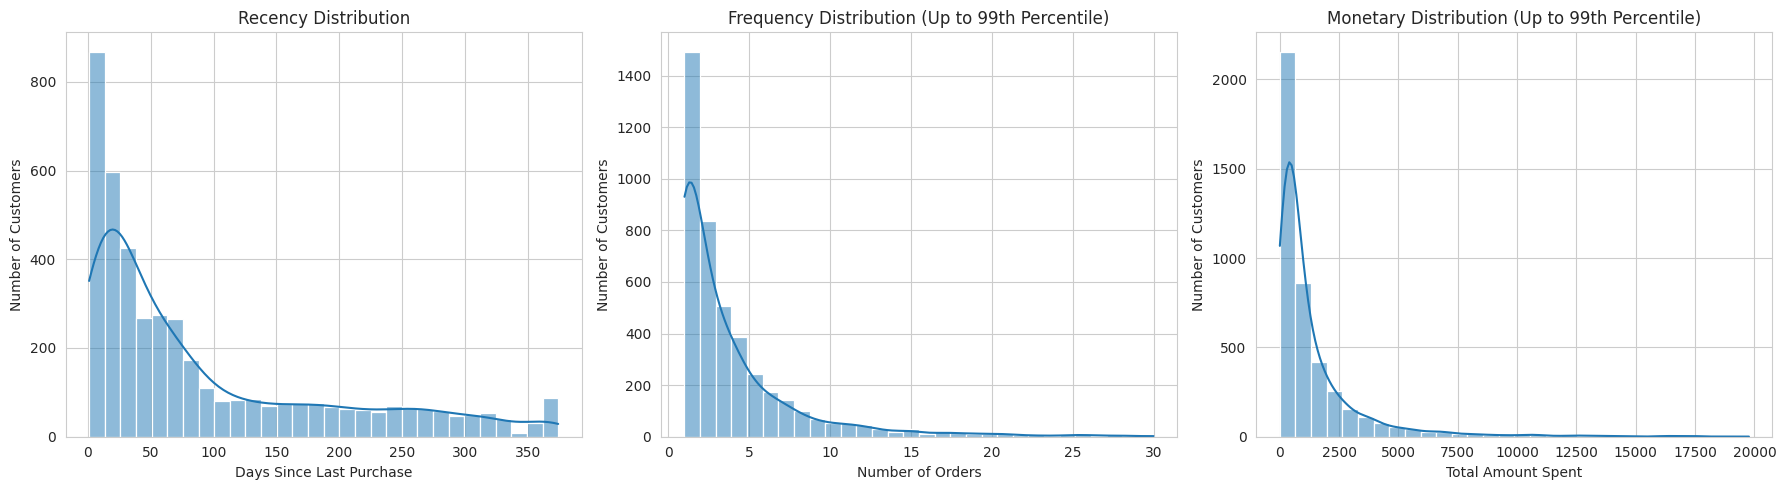

In [21]:
# ============================================================
# RFM DISTRIBUTION VISUALIZATIONS
# ============================================================

# Create a figure with 3 charts in one row.
plt.figure(figsize=(18, 5))

# ------------------------------------------------------------
# 1. Recency Distribution
# ------------------------------------------------------------
plt.subplot(1, 3, 1)

sns.histplot(
    rfm["Recency"],
    bins=30,
    kde=True
)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

# ------------------------------------------------------------
# 2. Frequency Distribution
# Remove top 1% values only for clearer visualization.
# ------------------------------------------------------------
plt.subplot(1, 3, 2)

frequency_limit = rfm["Frequency"].quantile(0.99)

sns.histplot(
    rfm[rfm["Frequency"] <= frequency_limit]["Frequency"],
    bins=30,
    kde=True
)

plt.title("Frequency Distribution (Up to 99th Percentile)")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

# ------------------------------------------------------------
# 3. Monetary Distribution
# Remove top 1% values only for clearer visualization.
# ------------------------------------------------------------
plt.subplot(1, 3, 3)

monetary_limit = rfm["Monetary"].quantile(0.99)

sns.histplot(
    rfm[rfm["Monetary"] <= monetary_limit]["Monetary"],
    bins=30,
    kde=True
)

plt.title("Monetary Distribution (Up to 99th Percentile)")
plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")

# Adjust spacing between charts.
plt.tight_layout()

# Display all charts.
plt.show()

### 4.3 RFM Outlier Treatment and Log Transformation

RFM features are often highly skewed because a small number of customers make many purchases or spend very large amounts. Log transformation reduces the impact of extreme values and makes the data more suitable for KMeans clustering.

In [22]:
# ============================================================
# RFM LOG TRANSFORMATION
# ============================================================

# Create a copy of the RFM dataset.
# This keeps the original RFM values unchanged for later interpretation.
rfm_transformed = rfm.copy()

# ------------------------------------------------------------
# Apply log transformation to Recency, Frequency, and Monetary.
#
# np.log1p(x) calculates log(1 + x).
# It is safe even when a value is 0.
# ------------------------------------------------------------
rfm_transformed["Recency_Log"] = np.log1p(rfm_transformed["Recency"])
rfm_transformed["Frequency_Log"] = np.log1p(rfm_transformed["Frequency"])
rfm_transformed["Monetary_Log"] = np.log1p(rfm_transformed["Monetary"])

# Display the first 5 rows with original and transformed values.
rfm_transformed.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Log,Frequency_Log,Monetary_Log
0,12346,326,1,77183.60,5.789960,0.693147,11.253955
1,12347,2,7,4310.00,1.098612,2.079442,8.368925
2,12348,75,4,1797.24,4.330733,1.609438,7.494564
3,12349,19,1,1757.55,2.995732,0.693147,7.472245
4,12350,310,1,334.40,5.739793,0.693147,5.815324


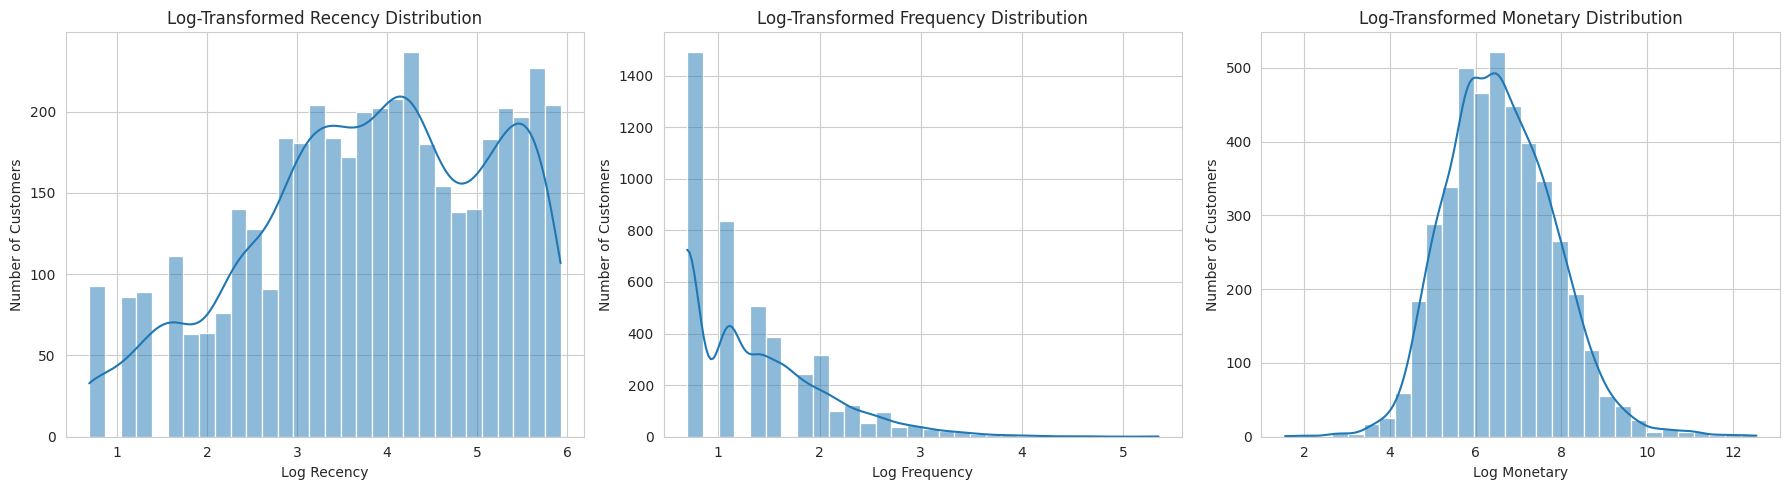

In [23]:
# ============================================================
# VISUALIZE LOG-TRANSFORMED RFM FEATURES
# ============================================================

# Create a figure with 3 charts in one row.
plt.figure(figsize=(18, 5))

# ------------------------------------------------------------
# 1. Log-Transformed Recency Distribution
# ------------------------------------------------------------
plt.subplot(1, 3, 1)

sns.histplot(
    rfm_transformed["Recency_Log"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed Recency Distribution")
plt.xlabel("Log Recency")
plt.ylabel("Number of Customers")

# ------------------------------------------------------------
# 2. Log-Transformed Frequency Distribution
# ------------------------------------------------------------
plt.subplot(1, 3, 2)

sns.histplot(
    rfm_transformed["Frequency_Log"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed Frequency Distribution")
plt.xlabel("Log Frequency")
plt.ylabel("Number of Customers")

# ------------------------------------------------------------
# 3. Log-Transformed Monetary Distribution
# ------------------------------------------------------------
plt.subplot(1, 3, 3)

sns.histplot(
    rfm_transformed["Monetary_Log"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed Monetary Distribution")
plt.xlabel("Log Monetary")
plt.ylabel("Number of Customers")

# Adjust spacing between charts.
plt.tight_layout()

# Display all charts.
plt.show()

### 4.4 Standardization of RFM Features

KMeans clustering is distance-based. Standardization converts all RFM features to a similar scale with mean approximately 0 and standard deviation approximately 1.

In [24]:
# ============================================================
# STANDARDIZATION OF RFM FEATURES
# ============================================================

# Import StandardScaler from Scikit-learn.
# StandardScaler standardizes features before KMeans clustering.
from sklearn.preprocessing import StandardScaler

# Select only the log-transformed RFM features for clustering.
rfm_features = rfm_transformed[
    ["Recency_Log", "Frequency_Log", "Monetary_Log"]
]

# Create the StandardScaler object.
scaler = StandardScaler()

# Standardize the RFM features.
# The result is a NumPy array with scaled values.
rfm_scaled_array = scaler.fit_transform(rfm_features)

# Convert the scaled NumPy array back into a DataFrame.
# This makes the values easier to read and use later.
rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    columns=["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]
)

# Display the first 5 standardized records.
rfm_scaled.head()

,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [25]:
# ============================================================
# STANDARDIZATION VERIFICATION
# ============================================================

# Display summary statistics of scaled features.
# Mean should be close to 0.
# Standard deviation should be close to 1.
print("Standardized RFM Feature Summary:")
display(rfm_scaled.describe().round(2))

Standardized RFM Feature Summary:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


##  Step 5: Customer Segmentation Using KMeans Clustering

### 5.1 Elbow Method for Cluster Selection

The Elbow Method is used to identify the suitable number of clusters for KMeans. It calculates inertia for different values of K. The best K is usually selected at the point where the inertia curve begins to flatten.

In [26]:
# ============================================================
# STEP 5.1: ELBOW METHOD FOR KMEANS CLUSTER SELECTION
# ============================================================

# Import KMeans clustering algorithm from Scikit-learn.
from sklearn.cluster import KMeans

# Create an empty list to store inertia values.
inertia_values = []

# Define the cluster values we want to test.
# We will test K values from 2 to 10.
k_values = range(2, 11)

# Run KMeans for each K value.
for k in k_values:

    # Create a KMeans model.
    # random_state=42 ensures the same result every time we run it.
    # n_init=10 runs KMeans 10 times and keeps the best result.
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train KMeans using standardized RFM features.
    kmeans.fit(rfm_scaled)

    # Store the inertia value for this K.
    inertia_values.append(kmeans.inertia_)

# Create a table showing K and inertia values.
elbow_results = pd.DataFrame({
    "Number of Clusters (K)": list(k_values),
    "Inertia": inertia_values
})

# Display elbow method results.
display(elbow_results)

,Number of Clusters (K),Inertia
0,2,6483.589424
1,3,4869.488628
2,4,3939.049382
3,5,3296.708707
4,6,2855.764067
5,7,2548.820243
6,8,2336.341052
7,9,2156.005672
8,10,2005.746235


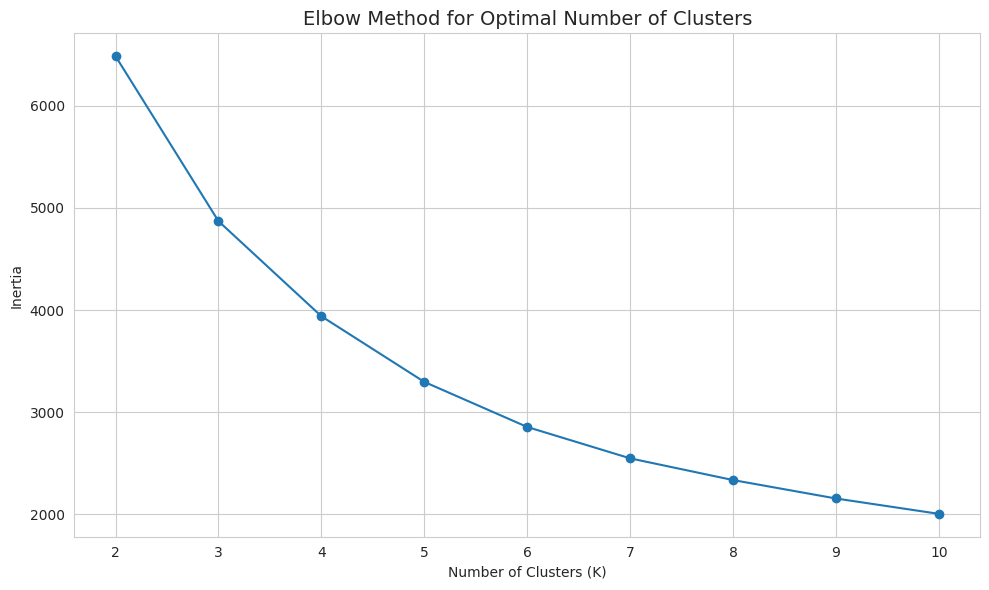

In [27]:
# ============================================================
# VISUALIZATION: ELBOW CURVE
# ============================================================

# Create a line chart for K values and inertia.
plt.figure(figsize=(10, 6))

# Plot the elbow curve.
plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

# Add chart title and axis labels.
plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

# Display all K values on the x-axis.
plt.xticks(list(k_values))

# Add grid lines for easier reading.
plt.grid(True)

# Adjust chart layout.
plt.tight_layout()

# Display the graph.
plt.show()

### 5.2 Silhouette Score Analysis

The Silhouette Score measures how well customers fit within their assigned clusters.

- Score close to +1 → Well-separated clusters
- Score around 0 → Overlapping clusters
- Score below 0 → Poor clustering

The cluster count with the highest silhouette score is generally preferred.

In [28]:
# ============================================================
# STEP 5.2: SILHOUETTE SCORE ANALYSIS
# ============================================================

from sklearn.metrics import silhouette_score

# Store silhouette scores
silhouette_scores = []

# Test K values from 2 to 10
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

# Create results table
silhouette_results = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
})

display(silhouette_results)

,K,Silhouette Score
0,2,0.432827
1,3,0.336517
2,4,0.337517
3,5,0.316200
4,6,0.312409
5,7,0.309186
6,8,0.303275
7,9,0.281085
8,10,0.276659


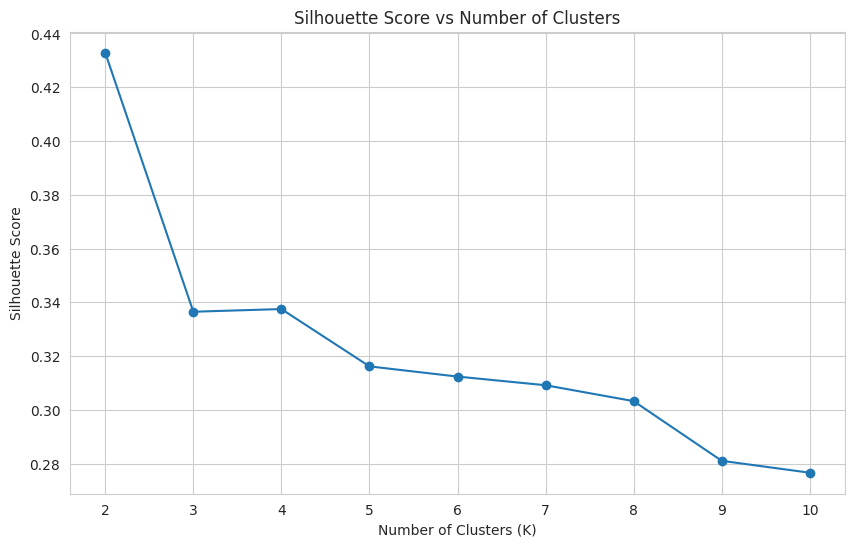

In [29]:
# ============================================================
# VISUALIZATION: SILHOUETTE SCORES
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2,11))
plt.grid(True)

plt.show()

### 5.3 Final KMeans Model Training

Based on the Elbow Method and business requirements, KMeans clustering is performed with 4 clusters. The clusters will later be interpreted as High-Value, Regular, Occasional, and At-Risk customer segments.

In [30]:
# ============================================================
# STEP 5.3: FINAL KMEANS MODEL TRAINING
# ============================================================

# Define the final number of clusters.
# We choose 4 clusters for meaningful business segmentation.
final_k = 4

# Create the final KMeans model.
final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

# Train the model and assign a cluster number to each customer.
rfm_transformed["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

# Add the cluster number to the original RFM dataset.
# This keeps original Recency, Frequency, and Monetary values
# available for easy business interpretation.
rfm["Cluster"] = rfm_transformed["Cluster"]

# Display the first 5 customers with their cluster assignment.
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [31]:
# ============================================================
# CLUSTER SIZE ANALYSIS
# ============================================================

# Count the number of customers in each cluster.
cluster_counts = rfm["Cluster"].value_counts().sort_index()

# Display cluster sizes.
print("Number of Customers in Each Cluster:")
display(cluster_counts)

Number of Customers in Each Cluster:


,count
Cluster,
0,713
1,1622
2,837
3,1166


### 5.4 Customer Cluster Profile Analysis

This section calculates the average Recency, Frequency, and Monetary values for each cluster. These averages help interpret the behavior of customers in every cluster and assign meaningful segment labels.

In [32]:
# ============================================================
# STEP 5.4: CUSTOMER CLUSTER PROFILE ANALYSIS
# ============================================================

# Group customers by Cluster.
# Calculate average Recency, Frequency, and Monetary values
# for every customer cluster.
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Monetary=("Monetary", "mean"),
        Customer_Count=("CustomerID", "count")
    )
    .round(2)
    .reset_index()
)

# Sort clusters by cluster number.
cluster_profile = cluster_profile.sort_values("Cluster")

# Display the customer cluster profile table.
print("Customer Cluster Profile:")
display(cluster_profile)

Customer Cluster Profile:


,Cluster,Average_Recency,Average_Frequency,Average_Monetary,Customer_Count
0,0,12.17,13.75,8088.02,713
1,1,181.51,1.32,341.00,1622
2,2,17.70,2.19,557.32,837
3,3,71.64,4.08,1801.78,1166


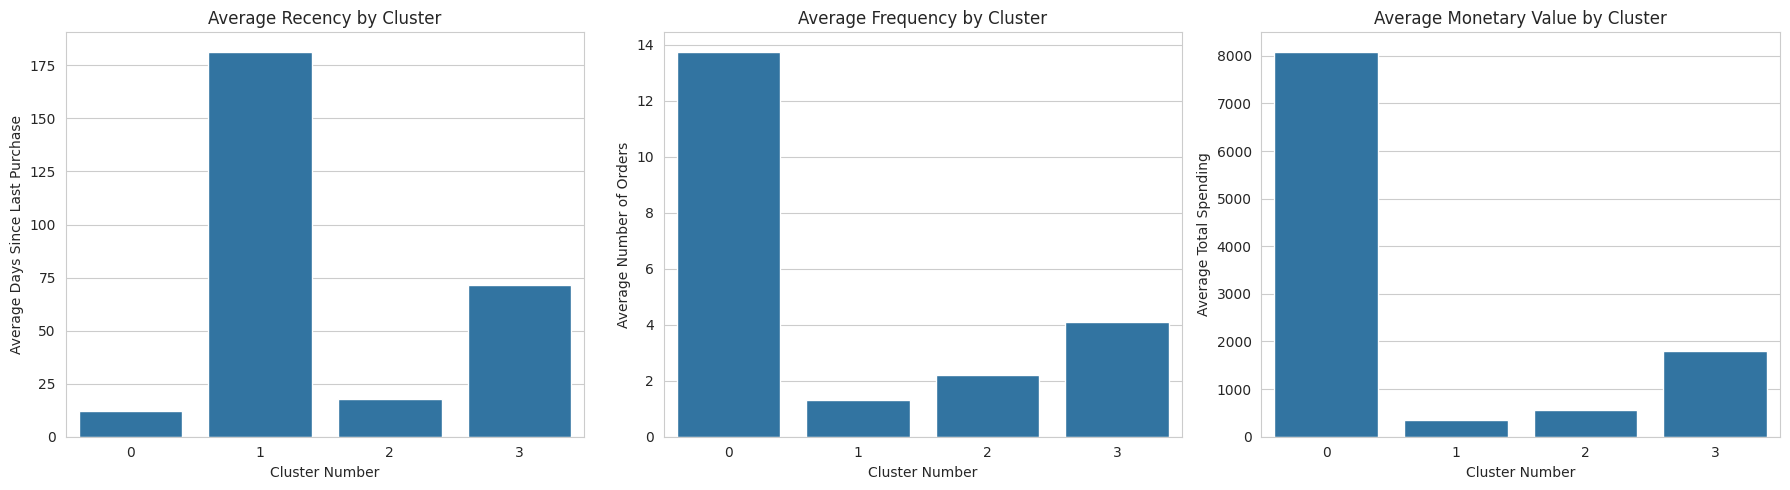

In [33]:
# ============================================================
# VISUALIZATION: CLUSTER PROFILE COMPARISON
# ============================================================

# Create a figure with 3 charts in one row.
plt.figure(figsize=(18, 5))

# ------------------------------------------------------------
# 1. Average Recency by Cluster
# ------------------------------------------------------------
plt.subplot(1, 3, 1)

sns.barplot(
    data=cluster_profile,
    x="Cluster",
    y="Average_Recency"
)

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Average Days Since Last Purchase")

# ------------------------------------------------------------
# 2. Average Frequency by Cluster
# ------------------------------------------------------------
plt.subplot(1, 3, 2)

sns.barplot(
    data=cluster_profile,
    x="Cluster",
    y="Average_Frequency"
)

plt.title("Average Frequency by Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Average Number of Orders")

# ------------------------------------------------------------
# 3. Average Monetary Value by Cluster
# ------------------------------------------------------------
plt.subplot(1, 3, 3)

sns.barplot(
    data=cluster_profile,
    x="Cluster",
    y="Average_Monetary"
)

plt.title("Average Monetary Value by Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Average Total Spending")

# Adjust spacing between charts.
plt.tight_layout()

# Display all charts.
plt.show()

### 5.5 Customer Segment Label Assignment

Based on the average Recency, Frequency, and Monetary values, each KMeans cluster is assigned a meaningful business segment label.

In [34]:
# ============================================================
# STEP 5.5: ASSIGN CUSTOMER SEGMENT LABELS
# ============================================================

# Create a dictionary that maps KMeans cluster numbers
# to meaningful customer segment names.
cluster_labels = {
    0: "High-Value",
    1: "At-Risk",
    2: "Occasional",
    3: "Regular"
}

# Create a new Segment column using the cluster label mapping.
rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

# Display the first 10 customers with their segment labels.
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Regular
1,12347,2,7,4310.00,0,High-Value
2,12348,75,4,1797.24,3,Regular
3,12349,19,1,1757.55,2,Occasional
4,12350,310,1,334.40,1,At-Risk
5,12352,36,8,2506.04,3,Regular
6,12353,204,1,89.00,1,At-Risk
7,12354,232,1,1079.40,1,At-Risk
8,12355,214,1,459.40,1,At-Risk
9,12356,23,3,2811.43,3,Regular


In [35]:
# ============================================================
# CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

# Count how many customers belong to each segment.
segment_counts = rfm["Segment"].value_counts()

# Display the number of customers in each segment.
print("Customer Count by Segment:")
display(segment_counts)

Customer Count by Segment:


,count
Segment,
At-Risk,1622
Regular,1166
Occasional,837
High-Value,713


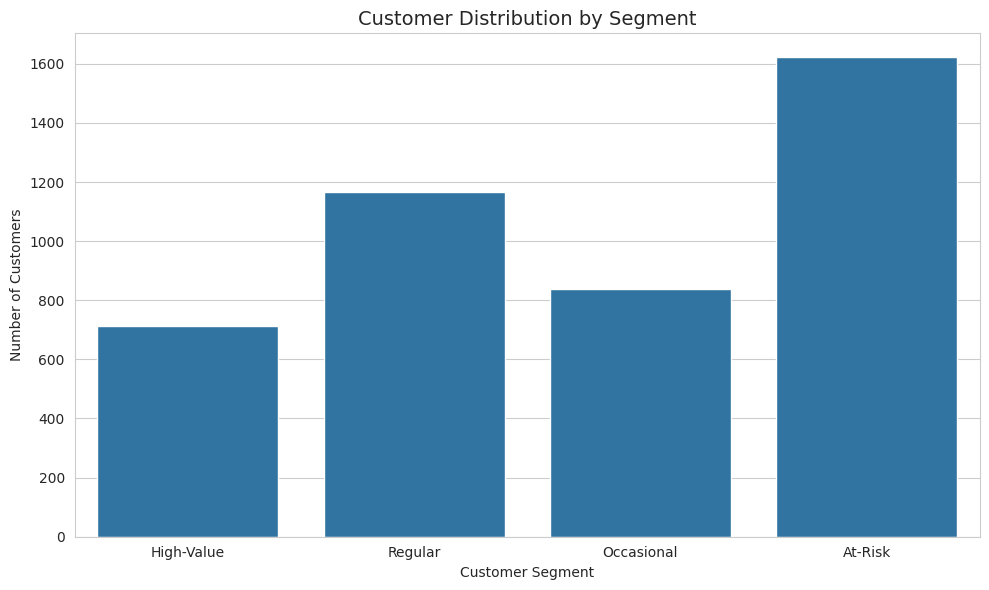

In [36]:
# ============================================================
# VISUALIZATION: CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

# Create a bar chart showing customer count in each segment.
plt.figure(figsize=(10, 6))

sns.countplot(
    data=rfm,
    x="Segment",
    order=["High-Value", "Regular", "Occasional", "At-Risk"]
)

# Add chart title and labels.
plt.title("Customer Distribution by Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Adjust layout.
plt.tight_layout()

# Display the chart.
plt.show()

### 5.6 Customer Cluster Visualization

This scatter plot visualizes customer segments using Recency and Monetary values. Each color represents a different customer segment created using KMeans clustering.

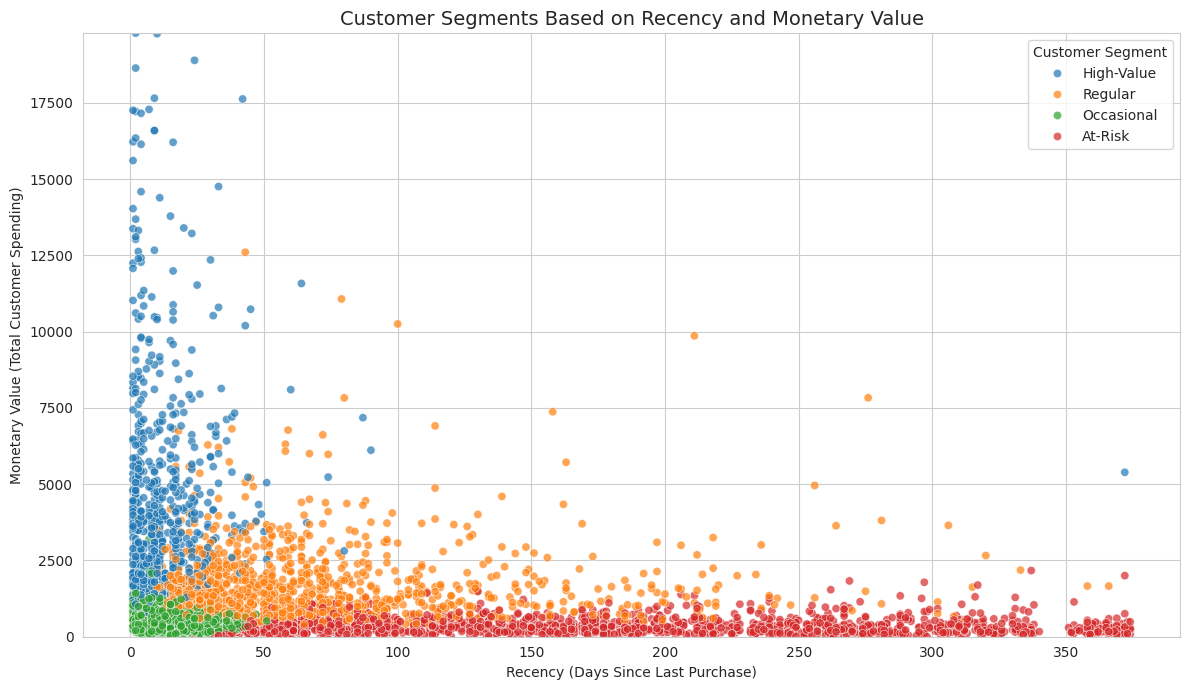

In [37]:
# ============================================================
# STEP 5.6: 2D CUSTOMER CLUSTER SCATTER PLOT
# ============================================================

# Create a scatter plot to visualize customer segments.
plt.figure(figsize=(12, 7))

# Plot customers using Recency and Monetary values.
# hue="Segment" assigns a different color to each segment.
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    hue_order=["High-Value", "Regular", "Occasional", "At-Risk"],
    alpha=0.7
)

# Limit Monetary axis to the 99th percentile.
# This prevents a few extreme high-spending customers
# from making the rest of the chart difficult to see.
plt.ylim(0, rfm["Monetary"].quantile(0.99))

# Add chart title and labels.
plt.title("Customer Segments Based on Recency and Monetary Value", fontsize=14)
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary Value (Total Customer Spending)")

# Display legend.
plt.legend(title="Customer Segment")

# Adjust layout.
plt.tight_layout()

# Display the chart.
plt.show()

##  Step 6: Item-Based Collaborative Filtering Product Recommendation System

### 6.1 Create Customer–Product Purchase Matrix

Item-based collaborative filtering recommends products based on products purchased by similar customers. A customer-product matrix is created where rows represent customers, columns represent products, and values represent purchased quantities.

In [38]:
# ============================================================
# STEP 6.1: PREPARE DATA FOR PRODUCT RECOMMENDATION
# ============================================================

# Count total quantity sold for every product.
# This helps us identify the most popular products.
product_sales = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

# Select the top 100 most-purchased products.
# Using popular products keeps the recommendation matrix smaller
# and faster to process.
top_100_products = product_sales.head(100).index

# Keep only transactions related to the top 100 products.
recommendation_data = df_clean[
    df_clean["Description"].isin(top_100_products)
].copy()

# Display the shape of recommendation dataset.
print("Recommendation Dataset Shape:", recommendation_data.shape)

# Display first 5 rows.
recommendation_data.head()

Recommendation Dataset Shape: (60885, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2022-12
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2022-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2022-12
35,536370,22629,SPACEBOY LUNCH BOX,24,2022-12-01 08:45:00,1.95,12583,France,46.80,2022-12
36,536370,22659,LUNCH BOX I LOVE LONDON,24,2022-12-01 08:45:00,1.95,12583,France,46.80,2022-12
39,536370,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2022-12-01 08:45:00,1.65,12583,France,39.60,2022-12


In [39]:
# ============================================================
# CREATE CUSTOMER-PRODUCT PURCHASE MATRIX
# ============================================================

# Create a customer-product matrix.
#
# Rows    -> CustomerID
# Columns -> Product Description
# Values  -> Total quantity purchased by the customer
#
# fill_value=0 replaces missing customer-product combinations with 0.
customer_product_matrix = pd.pivot_table(
    recommendation_data,
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

# Display the matrix shape.
print("Customer-Product Matrix Shape:", customer_product_matrix.shape)

# Display a small sample of the matrix.
customer_product_matrix.iloc[:5, :5]

Customer-Product Matrix Shape: (3883, 100)


Description,6 RIBBONS RUSTIC CHARM,60 CAKE CASES VINTAGE CHRISTMAS,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,AGED GLASS SILVER T-LIGHT HOLDER
CustomerID,,,,,
12346,0,0,0,0,0
12347,0,0,72,72,0
12348,0,144,144,72,0
12349,0,0,0,0,0
12350,0,0,0,0,0


### 6.2 Product Similarity Using Cosine Similarity

Cosine similarity is used to calculate how similar products are based on customer purchase behavior. Products frequently purchased by the same customers will receive higher similarity scores.

In [40]:
# ============================================================
# STEP 6.2: PRODUCT SIMILARITY USING COSINE SIMILARITY
# ============================================================

# Import cosine_similarity from Scikit-learn.
# It calculates similarity between product purchase patterns.
from sklearn.metrics.pairwise import cosine_similarity

# Transpose the customer-product matrix.
#
# Before transpose:
# Rows    -> Customers
# Columns -> Products
#
# After transpose:
# Rows    -> Products
# Columns -> Customers
#
# We need products as rows to calculate product-to-product similarity.
product_customer_matrix = customer_product_matrix.T

# Calculate cosine similarity between all products.
product_similarity_array = cosine_similarity(product_customer_matrix)

# Convert similarity array into a DataFrame.
# Product names are used as both rows and columns.
product_similarity_df = pd.DataFrame(
    product_similarity_array,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

# Display a small part of the similarity matrix.
product_similarity_df.iloc[:5, :5]

Description,6 RIBBONS RUSTIC CHARM,60 CAKE CASES VINTAGE CHRISTMAS,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,AGED GLASS SILVER T-LIGHT HOLDER
Description,,,,,
6 RIBBONS RUSTIC CHARM,1.000000,0.147064,0.202887,0.165655,0.020563
60 CAKE CASES VINTAGE CHRISTMAS,0.147064,1.000000,0.235598,0.195380,0.004670
60 TEATIME FAIRY CAKE CASES,0.202887,0.235598,1.000000,0.939350,0.004725
72 SWEETHEART FAIRY CAKE CASES,0.165655,0.195380,0.939350,1.000000,0.010200
AGED GLASS SILVER T-LIGHT HOLDER,0.020563,0.004670,0.004725,0.010200,1.000000


In [41]:
# ============================================================
# FUNCTION: GET TOP 5 PRODUCT RECOMMENDATIONS
# ============================================================

def get_product_recommendations(product_name, top_n=5):
    """
    Returns top similar products based on cosine similarity.

    Parameters:
    product_name : Name of the product entered by the user
    top_n        : Number of recommendations to return

    Returns:
    DataFrame containing recommended product names and similarity scores
    """

    # Convert user input to uppercase.
    # Product descriptions in this dataset are mostly uppercase.
    product_name = product_name.upper().strip()

    # Check whether the entered product exists in the similarity matrix.
    if product_name not in product_similarity_df.index:
        return f"Product '{product_name}' not found. Please enter a product from the available product list."

    # Get similarity scores for the selected product.
    similarity_scores = product_similarity_df[product_name]

    # Sort products by similarity score in descending order.
    # Remove the selected product itself using [1:].
    similar_products = similarity_scores.sort_values(
        ascending=False
    )[1:top_n + 1]

    # Convert results into a DataFrame.
    recommendations = pd.DataFrame({
        "Recommended Product": similar_products.index,
        "Similarity Score": similar_products.values.round(3)
    })

    return recommendations

In [42]:
# ============================================================
# TEST PRODUCT RECOMMENDATION FUNCTION
# ============================================================

# Select one product from the matrix columns.
# This guarantees that the product name exists.
test_product = customer_product_matrix.columns[0]

# Print selected product name.
print("Selected Product:", test_product)

# Get top 5 similar products.
get_product_recommendations(test_product)

Selected Product: 6 RIBBONS RUSTIC CHARM


,Recommended Product,Similarity Score
0,LUNCH BAG APPLE DESIGN,0.579
1,SPACEBOY LUNCH BOX,0.567
2,LUNCH BAG SPACEBOY DESIGN,0.527
3,DOLLY GIRL LUNCH BOX,0.515
4,SET OF 60 PANTRY DESIGN CAKE CASES,0.508


### 6.3 Product Similarity Heatmap

This heatmap visualizes cosine similarity scores between selected popular products. Higher similarity values indicate that products are frequently purchased by similar customers.

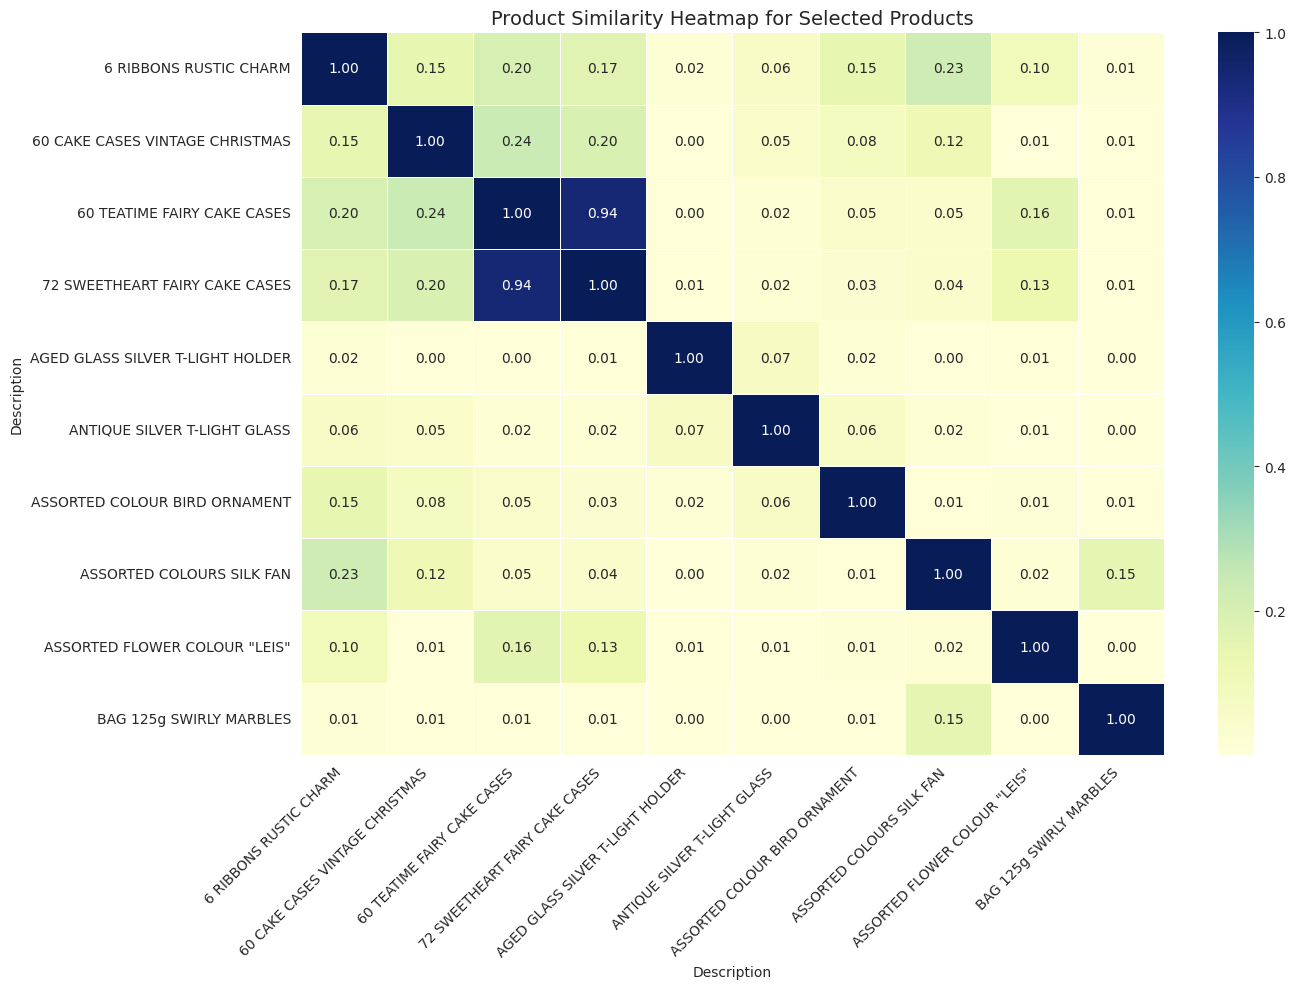

In [43]:
# ============================================================
# STEP 6.3: PRODUCT SIMILARITY HEATMAP
# ============================================================

# Select the first 10 products from the similarity matrix.
# We use only 10 products so the heatmap remains readable.
selected_products = product_similarity_df.index[:10]

# Create a smaller similarity matrix using selected products.
similarity_heatmap_data = product_similarity_df.loc[
    selected_products,
    selected_products
]

# Create the heatmap.
plt.figure(figsize=(14, 10))

sns.heatmap(
    similarity_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

# Add chart title.
plt.title("Product Similarity Heatmap for Selected Products", fontsize=14)

# Rotate product names for better readability.
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Adjust layout.
plt.tight_layout()

# Display the heatmap.
plt.show()

##  Step 7: Save Models for Streamlit Deployment

This section saves the trained KMeans clustering model, scaler, product similarity matrix, and cluster label mapping. These files will be loaded later in the Streamlit web application.

In [44]:
# ============================================================
# STEP 7: SAVE MODELS AND RECOMMENDATION FILES
# ============================================================

# Import joblib.
# joblib is used to save and load machine learning models.
import joblib

# ------------------------------------------------------------
# Save the trained KMeans clustering model.
# This model will predict the customer cluster in Streamlit.
# ------------------------------------------------------------
joblib.dump(final_kmeans, "kmeans_customer_segmentation_model.pkl")

# ------------------------------------------------------------
# Save the StandardScaler.
# The Streamlit app must use the same scaler that was used
# while training the KMeans model.
# ------------------------------------------------------------
joblib.dump(scaler, "rfm_scaler.pkl")

# ------------------------------------------------------------
# Save the product similarity matrix.
# This matrix is used to recommend similar products.
# ------------------------------------------------------------
joblib.dump(product_similarity_df, "product_similarity_matrix.pkl")

# ------------------------------------------------------------
# Save the list of available products.
# This can be used in Streamlit dropdown/search functionality.
# ------------------------------------------------------------
joblib.dump(
    list(product_similarity_df.index),
    "available_products.pkl"
)

# ------------------------------------------------------------
# Save cluster number to segment name mapping.
# ------------------------------------------------------------
joblib.dump(cluster_labels, "cluster_labels.pkl")

# Display success message.
print("All model files saved successfully.")

All model files saved successfully.


In [45]:
# ============================================================
# VERIFY SAVED FILES
# ============================================================

# Import os module to check saved files.
import os

# Create a list of expected saved files.
saved_files = [
    "kmeans_customer_segmentation_model.pkl",
    "rfm_scaler.pkl",
    "product_similarity_matrix.pkl",
    "available_products.pkl",
    "cluster_labels.pkl"
]

# Check whether each file exists.
for file_name in saved_files:
    if os.path.exists(file_name):
        print(f"✅ {file_name} saved successfully")
    else:
        print(f"❌ {file_name} was not found")

✅ kmeans_customer_segmentation_model.pkl saved successfully
✅ rfm_scaler.pkl saved successfully
✅ product_similarity_matrix.pkl saved successfully
✅ available_products.pkl saved successfully
✅ cluster_labels.pkl saved successfully


In [46]:
# ============================================================
# STEP 8: DOWNLOAD MODEL FILES FROM GOOGLE COLAB
# ============================================================

# Import files module from Google Colab.
# This allows downloading files from Colab to your computer.
from google.colab import files

# Download the trained KMeans model.
files.download("kmeans_customer_segmentation_model.pkl")

# Download the fitted StandardScaler.
files.download("rfm_scaler.pkl")

# Download the product similarity matrix.
files.download("product_similarity_matrix.pkl")

# Download the available product list.
files.download("available_products.pkl")

# Download the cluster label mapping.
files.download("cluster_labels.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>